<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/04-30-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!mkdir -p ~/.kaggle

In [38]:
!cp kaggle.json ~/.kaggle/

In [39]:
!chmod 600 ~/.kaggle/kaggle.json

In [40]:
!kaggle competitions download -c bike-sharing-demand

bike-sharing-demand.zip: Skipping, found more recently modified local copy (use --force to force download)


In [41]:
!unzip bike-sharing-demand.zip

Archive:  bike-sharing-demand.zip
replace sampleSubmission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [154]:
import pandas as pd

train_df=pd.read_csv('train.csv')
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [155]:
test_df=pd.read_csv('test.csv')
test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014
...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981


In [156]:
# train - casual, registered 불필요
# 년, 월, 일, 시간 -> 새로운 열로 삽입
# 타겟 / 피처 분리해서 -> 텐서로 변환 후
# 딥러닝 모델 정의(linear 3개, dropout, relu)

# mseloss, adam
# => 따릉이 대여량과 피처들간의 상관관계

In [157]:
def preprocess(df):
  df['datetime']=pd.to_datetime(df['datetime'])
  df['year']=df['datetime'].dt.year

preprocess(train_df)

In [158]:
train_df['year']=train_df['datetime'].dt.year
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012


In [159]:
train_df['month']=train_df['datetime'].dt.month
train_df['day']=train_df['datetime'].dt.day
train_df['hour']=train_df['datetime'].dt.hour
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,12,19,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,12,19,20
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,21
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,22


In [160]:
features=train_df.drop(['casual', 'registered', 'count','datetime'],axis=1)
features

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0000,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0000,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0000,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0000,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0000,2011,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,2012,12,19,19
10882,4,0,1,1,14.76,17.425,57,15.0013,2012,12,19,20
10883,4,0,1,1,13.94,15.910,61,15.0013,2012,12,19,21
10884,4,0,1,1,13.94,17.425,61,6.0032,2012,12,19,22


In [161]:
target=train_df['count']
target

,count
0,16
1,40
2,32
3,13
4,1
...,...
10881,336
10882,241
10883,168
10884,129


In [162]:
features.isna().sum()

,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
year,0
month,0


In [163]:
target.isna().sum()

np.int64(0)

In [164]:
import torch
import torch.nn as nn
import torch.optim as optim

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [167]:
X_train, X_test, y_train, y_test = train_test_split(
    features.values, target.values, test_size=0.2, shuffle=False
)

In [168]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [169]:
# 텐서 변환
X_train_tensor=torch.tensor(X_train_scaled).float()
X_test_tensor=torch.tensor(X_test_scaled).float()
print(X_train_tensor.shape, X_test_tensor.shape)

torch.Size([8708, 12]) torch.Size([2178, 12])


In [171]:
y_train_tensor = torch.tensor(y_train).float().unsqueeze(1)
y_test_tensor = torch.tensor(y_test).float().unsqueeze(1)
print(y_train_tensor.shape, y_test_tensor.shape)

torch.Size([8708, 1]) torch.Size([2178, 1])


In [172]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [173]:
train_loader=DataLoader(train_dataset, batch_size=128, shuffle=True)
vaild_loader=DataLoader(train_dataset, batch_size=128, shuffle=False)

test_loader=DataLoader(test_dataset, batch_size=128, shuffle=False)

In [174]:
class BicycleModel(nn.Module):
    def __init__(self, input_dim):
        super(BicycleModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [175]:
model = BicycleModel(train_dataset.tensors[0].shape[1])

In [176]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [177]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [185]:
epochs=500
train_loss, valid_loss=[], []
model.to(device)

for epoch in range(epochs):
    # --- 학습 단계 ---
    model.train()
    train_total_loss = 0
    for X_batch, y_batch in train_loader:
        # 데이터를 모델과 동일한 장치로 이동
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_total_loss += loss.item()

    avg_train_loss = train_total_loss / len(train_loader)
    train_loss.append(avg_train_loss)

    # --- 검증 단계 ---
    model.eval()
    valid_total_loss = 0
    with torch.no_grad(): # 기울기 계산 비활성화 (메모리 절약)
        for X_val, y_val in vaild_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            y_val_pred = model(X_val)
            val_loss = criterion(y_val_pred, y_val)
            valid_total_loss += val_loss.item()

    avg_valid_loss = valid_total_loss / len(vaild_loader)
    valid_loss.append(avg_valid_loss)

print(train_loss, valid_loss)



[16272.686367753624, 16160.608133067255, 16324.74658910779, 16409.068189538044, 16629.35251075634, 16360.00243432971, 16340.946911798008, 16178.68215013587, 16381.604378962862, 16231.147835994112, 16252.355235224184, 16189.873103487318, 16199.848908797554, 16238.016530797102, 17247.841259057972, 16366.234615602356, 16361.835880887682, 16356.32368800951, 16309.790265511776, 16841.986045063404, 16203.77536231884, 16158.847013169441, 16416.258222939312, 16115.460873811142, 16075.829996744791, 16545.829879981884, 16244.985319718071, 16160.381209663723, 16315.556640625, 16284.926658740942, 16291.983016304348, 16205.75685009058, 16594.82034080616, 16269.85205785779, 16162.46875, 16574.19624660326, 16142.90425441576, 16764.7490942029, 16454.444746376812, 16239.337451879528, 16022.472804857336, 16251.624674479166, 16092.075060858242, 16168.536387567934, 16033.612672667572, 16195.11128566576, 16248.657920063406, 16148.271590523098, 16494.488139719204, 16122.350642549818, 16160.125806725544, 159

평균 오차(RMSE): 약 98.54대


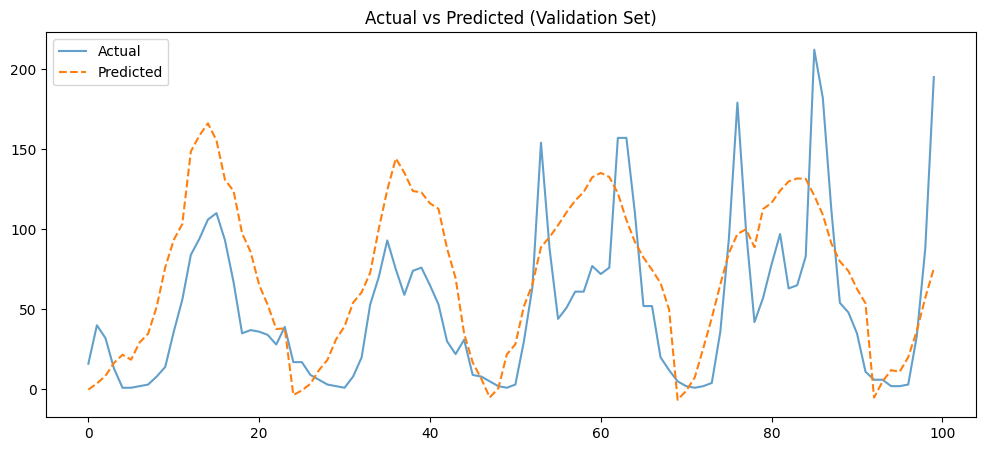

In [186]:
import numpy as np

model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for X_val, y_val in vaild_loader:
        X_val = X_val.to(device)
        preds = model(X_val)
        all_preds.extend(preds.cpu().numpy())
        all_actuals.extend(y_val.numpy())

# RMSE 계산 (오차의 평균 대수)
rmse = np.sqrt(np.mean((np.array(all_preds) - np.array(all_actuals))**2))
print(f"평균 오차(RMSE): 약 {rmse:.2f}대")

# 실제값 vs 예측값 비교 그래프 (앞 100개 데이터)
plt.figure(figsize=(12, 5))
plt.plot(all_actuals[:100], label='Actual', alpha=0.7)
plt.plot(all_preds[:100], label='Predicted', linestyle='--')
plt.title('Actual vs Predicted (Validation Set)')
plt.legend()
plt.show()
